# Re-Organizing Behavioural Data

In [1]:
from scipy.io import loadmat
import pandas as pd
import numpy as np
import h5py
import matplotlib.pyplot as plt
import os

In [2]:
mouse = "cfm001mjr"
base_path = "/Users/katiebrown/Library/CloudStorage/OneDrive-Stanford/Neuro_Project/Data/Behavioral_Data/"
path_behavior = base_path + mouse + "/PerceptualData_" + mouse +"_all.mat"
path_movie = "/Users/katiebrown/Library/CloudStorage/OneDrive-Stanford/Neuro_Project/Data/cG_unmixed_dFF.h5"

## Generating dataframe and CSV File for trial info

### Helper Functions for gen_trial_info()

In [85]:
def flatten_cell(cell):
    # Handle nested lists or arrays
    if isinstance(cell, (list, np.ndarray)):
        return cell[0] if len(cell) > 0 else None  # Extract the first element if not empty
    return cell

def perceptual_category(df, data_behavior):
    percept_cats = pd.DataFrame(data_behavior["ConCrit"])

    # Extract min and max contrast values from percept_cats
    min_values = percept_cats.iloc[1:, 0].to_list()  # First column (min values)
    max_values = percept_cats.iloc[1:, 1].to_list()  # Second column (max values)
    bins = [min_values[0]] + max_values  # Combine min start and max values to define bin edges

    # Use pd.cut to categorize contrasts
    categories = pd.cut(
        df["Contrast"],
        bins=bins,  # Bin edges
        labels=[1, 2, 3],  # Assign category labels
        right=True,  # Include the right edge of bins
        include_lowest=True # Include 0 for category 1
    )

    # Add the new column to the DataFrame
    df.insert(5, "PerceptualCat", categories)
    return df

def categorize_trial(row):
    """
    Categorizes a trial based on perceptual category, reaction time, reward, enticement, and attrition.
    Returns a string with the trial type label.

    Args:
    - row (pd.Series): A row from the dataframe.

    Returns:
    - str: Trial type name with number.
    """

    if (row["ReactTime"] < 0.25) or (row["Enticed?"] == 1) or ((row["Rewarded?"] == 1) and (row["Consume?"] == 0)):
        return "Error (0)"

    # Assign valid trials to categories
    if row["Rewarded?"] == 1 and row["Attrition?"] == 0:
        if row["PerceptualCat"] == 1:
            return "False Alarm (1)"
        elif row["PerceptualCat"] == 2:
            return "MC Hit (2)"
        elif row["PerceptualCat"] == 3:
            return "HC Hit (3)"
    
    if row["Rewarded?"] == 0 and row["Attrition?"] == 0:
        if row["PerceptualCat"] == 1:
            return "Correct Rejection (4)"
        elif row["PerceptualCat"] == 2:
            return "MC Miss (5)"
        elif row["PerceptualCat"] == 3:
            return "Incorrect Reject (6)"

    if row["Rewarded?"] == 0 and row["Attrition?"] == 1:
        if row["PerceptualCat"] == 1:
            return "LC No Report (7)"
        elif row["PerceptualCat"] == 2:
            return "MC No Report (8)"
        elif row["PerceptualCat"] == 3:
            return "HC No Report (9)"
    
    return "Uncategorized"

def map_recording_files(df):
    """
    Loads the Volt_<date>.mat file for each mouse and date in df and maps the correct
    recording file numbers to df.

    Args:
    - df (pd.DataFrame): The dataframe containing trial information, including 'AnimalCode', 'Date', and 'Recording'.

    Returns:
    - pd.DataFrame: The updated dataframe with a new column 'RecordingFileNum' containing the correct file number.
    """
    base_path = "/Volumes/T7 Shield2/BehaviorDataBackup/VoltageMice/"
    recording_file_map = {}

    # Identify unique (mouse, date) pairs
    unique_pairs = df[["AnimalCode", "Date"]].drop_duplicates()

    for _, row in unique_pairs.iterrows():
        mouse = row["AnimalCode"]
        date = row["Date"]
        mat_path = f"{base_path}{mouse}/Volt_{date}.mat"

        try:
            # Load the MATLAB file
            mat_data = loadmat(mat_path, struct_as_record=False, squeeze_me=True)
            
            # Extract the 'RESULTS' table
            results = mat_data["RESULTS"]
            
            # Extract the file numbers column
            file_numbers = results[1:, 4]  # Column 5 (index 4) contains file numbers
            
            # Create a mapping of (mouse, date) -> ordered file numbers
            recording_file_map[(mouse, date)] = list(file_numbers)
        
        except Exception as e:
            print(f"⚠️ Error loading {mat_path}: {e}")
            recording_file_map[(mouse, date)] = None  # Store None if loading fails

    # Map the correct file number to each row in df
    def get_recording_file_num(row):
        file_list = recording_file_map.get((row["AnimalCode"], row["Date"]), [])
        if file_list and row["Recording"] <= len(file_list):
            return file_list[row["Recording"] - 1]  # Adjust for zero-indexing
        return None  # Return None if something is missing

    df["File"] = df.apply(get_recording_file_num, axis=1) - 1
    df["File"] = 'meas0' + df["File"].astype(str)
    
    return df

def trial_category(df, print_results=False):
    # Apply function to each row
    df["TrialType"] = df.apply(categorize_trial, axis=1)

    if print_results:
        # Print summary
        print("\nTrial Type Summary:")
        summary = df["TrialType"].value_counts()
        for category, count in summary.items():
            print(f"{category}: {count} trials")

    return df

# Add column for trialID
def trial_ID(df):
    df['TrialID'] = 'Visual/' + str(mouse) + '/20' + df['Date'].astype(str) + '/meas' + df['Recording#'].astype(str).str.zfill(2) + '/trial' + df['Trial'].astype(str).str.zfill(3)
    return df

# Precompute delays for each unique (date, mouse) pair
def compute_delays(df):
    """
    Computes delays for each unique (Date, AnimalCode, Recording#) combination.

    Args:
    - df (pd.DataFrame): DataFrame containing 'Date', 'AnimalCode', and 'Recording#'.

    Returns:
    - dict: A dictionary with keys (Date, AnimalCode, Recording#) mapping to average delay.
    """
    delay_cache = {}
    basePath = "/Users/katiebrown/Library/CloudStorage/OneDrive-Stanford/Neuro_Project/Data/Behavioral_Data/"

    # Find unique (Date, AnimalCode, Recording#) combinations
    unique_pairs = df[["Date", "AnimalCode", "Recording#"]].drop_duplicates()

    for _, row in unique_pairs.iterrows():
        date = row["Date"]
        mouse = row["AnimalCode"]
        recording = row["Recording#"]
        path2 = f"{basePath}{mouse}/Volt_{date}_processed.mat"

        # Load the file
        data2 = loadmat(path2)
        df2 = pd.DataFrame(data2["MasterN"]).map(flatten_cell).map(flatten_cell).map(flatten_cell)

        # Ensure column names are correctly set
        df2.columns = df2.iloc[0]  
        df2 = df2[1:]  

        # Extract FrameAlignmentInfo for the correct recording
        delayEstimates = df2['FrameAlignmentInfo'][recording][0][0]

        # Compute mean delay for the recording
        delay_cache[(date, mouse, recording)] = np.mean(delayEstimates)

    return delay_cache

def bfm_time(df):
    delay_cache = compute_delays(df)  # Precompute delays
    df["Delay"] = df.apply(lambda row: delay_cache.get((row["Date"], row["AnimalCode"], row["Recording#"]), np.nan), axis=1)

    ######### Will need to update ##########
    filepath_mov = "/Users/katiebrown/Library/CloudStorage/OneDrive-Stanford/Neuro_Project/Data/cG_unmixed_dFF.h5"
    with h5py.File(filepath_mov, 'r') as mov_file:
        specs = mov_file["specs"]
        fps = specs["fps"][()][0][0]
        timeorigin = specs["timeorigin"][()][0][0] 

    df["BFMTime"] = df["Time"] - df["Delay"] - int(timeorigin[0])/fps  # Compute BFM time
    df.drop(columns=["Delay"], inplace=True)
    return df

def filter_vdt_trials(df, xlsx_path):
    """
    Filters trials from df to include only those where the corresponding recording has Task = 'VDT'.
    
    Args:
    - df (pd.DataFrame): The trial dataframe containing 'Date', 'File', and 'AnimalCode'.
    - xlsx_path (str): Path to the xlsx file.
    - sheet_name (str): The name of the sheet containing recording metadata.
    
    Returns:
    - pd.DataFrame: The filtered dataframe containing only trials with Task = 'VDT'.
    """

    recording_info = pd.read_excel(xlsx_path, sheet_name="Sheet1")

    df2 = df.copy()

    df2["Date"] = df2["Date"].astype(str)
    recording_info["Date"] = recording_info["Date"].astype(str).str[2:]  # Convert YYYYMMDD → YYMMDD
    recording_info = recording_info.rename(columns={"Animal": "AnimalCode"})

    #Merge df with the xlsx data to bring in the Task column
    merged_df = df2.merge(
        recording_info,
        left_on=["AnimalCode", "Date", "File"],
        right_on=["AnimalCode", "Date", "File"],
        how="left"
    )

    # Identify recordings where Task is not 'VDT'
    flagged_recordings = merged_df.loc[merged_df["Task"] != "VDT", ["AnimalCode", "Date", "File"]].drop_duplicates()

    # Identify recordings missing from the xlsx file
    missing_recordings = merged_df.loc[merged_df["Task"].isna(), ["AnimalCode", "Date", "File"]].drop_duplicates()

    # Print missing recordings
    if not missing_recordings.empty:
        print()
        print("⚠️ The following recordings were not found in the xlsx file:")
        print(missing_recordings.to_string(index=False))

    # Print flagged recordings
    if not flagged_recordings.empty:
        print()
        print("⚠️ The following recordings were flagged for removal (Task != 'VDT'):")
        print(flagged_recordings.to_string(index=False))

    # # Keep only trials where Task is 'VDT'
    merged_df = merged_df[merged_df["Task"] == "VDT"].copy()
    merged_df.drop(columns=['Record#', 'identifier', 'Task', 'Active', 'VDT Behavior Quality.1'], inplace=True)

    return merged_df

In [86]:
def gen_trial_info(mouse, path_behavior, path_movie):
    data_behavior = loadmat(path_behavior)
    df = pd.DataFrame(data_behavior["TrialInfo"]).map(flatten_cell).map(flatten_cell)

    with h5py.File(path_movie, 'r') as mov_file:
        specs = mov_file["specs"]
        fps = specs["fps"][()][0][0][0]
        timeorigin = specs["timeorigin"][()][0][0][0]

    # Set the second row as the header (column names)
    df.columns = df.iloc[0]                    # Assign the second row as column names
    df = df[1:]                                # Remove the first row (now redundant)
    df.reset_index(drop=True, inplace=True)    # Reset the index to start from 0

    trial_ID(df)
    perceptual_category(df, data_behavior)
    trial_category(df, print_results=True)
    bfm_time(df)
    df = df.rename(columns={"Recording#": "Recording"})
    df = map_recording_files(df)
    
    xlsx_path = "/Users/katiebrown/Library/CloudStorage/OneDrive-Stanford/Neuro_Project/Data/Behavioral_Data/RecordingLogsVoltage.xlsx"
    df = filter_vdt_trials(df, xlsx_path)

    # Rearrange columns and drop redundant ones
    df.drop(columns=["Trial"], inplace=True)

    order = ['TrialID', 'TrialType', 'AnimalCode', 'Date', 'Recording', 'File', 'Time', 'BFMTime', 
             'Duration', 'Contrast', 'PerceptualCat', 'ReactTime', 'Rewarded?', 'Enticed?', 'Seen?', 'Consume?', 
             'Attrition?', 'EngagementScore', 'EngagementScore_S20', 'VDT Behavior Quality']
    df = df[[col for col in order if col in df.columns]]    # Reorder the DataFrame columns

    return df

df = gen_trial_info(mouse, path_behavior, path_movie)

csv_path = "/Users/katiebrown/Library/CloudStorage/OneDrive-Stanford/Neuro_Project/Data/Behavioral_Data/cfm001mjr/TrialInfo.csv"
df.to_csv(csv_path, index=False)

df


Trial Type Summary:
LC No Report (7): 553 trials
HC No Report (9): 502 trials
MC No Report (8): 490 trials
Error (0): 300 trials
HC Hit (3): 171 trials
Correct Rejection (4): 164 trials
MC Miss (5): 119 trials
MC Hit (2): 101 trials
Incorrect Reject (6): 79 trials
False Alarm (1): 22 trials
Uncategorized: 2 trials

⚠️ The following recordings were flagged for removal (Task != 'VDT'):
AnimalCode   Date   File
 cfm001mjr 240522 meas00


,TrialID,TrialType,AnimalCode,Date,Recording,File,Time,BFMTime,Duration,Contrast,PerceptualCat,ReactTime,Rewarded?,Enticed?,Seen?,Consume?,Attrition?,EngagementScore,EngagementScore_S20,VDT Behavior Quality
0,Visual/rfm002mjr/20240506/meas01/trial001,HC No Report (9),cfm001mjr,240506,1,meas00,3.198,1.824719,0.529,0.06,3,11.88,0,0,0,0,1,0,0,56.0
1,Visual/rfm002mjr/20240506/meas01/trial002,LC No Report (7),cfm001mjr,240506,1,meas00,6.353,4.979719,0.522,0.023,1,8.725,0,0,0,0,1,0,0,56.0
2,Visual/rfm002mjr/20240506/meas01/trial003,LC No Report (7),cfm001mjr,240506,1,meas00,10.228,8.854719,0.532,0,1,4.85,0,0,0,0,1,0,0.057143,56.0
3,Visual/rfm002mjr/20240506/meas01/trial004,Error (0),cfm001mjr,240506,1,meas00,14.599,13.225719,0.521,0.024,1,0.479,1,1,1,1,1,0.285714,0.086735,56.0
4,Visual/rfm002mjr/20240506/meas01/trial005,LC No Report (7),cfm001mjr,240506,1,meas00,43.217,41.843719,0.55,0.023,1,4.464,0,0,0,0,1,0,0.130952,56.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2229,Visual/rfm002mjr/20240518/meas01/trial183,MC No Report (8),cfm001mjr,240518,1,meas00,909.467,907.726955,0.502,0.035,2,NaN,0,0,0,0,1,0,0,21.0
2230,Visual/rfm002mjr/20240518/meas01/trial184,MC No Report (8),cfm001mjr,240518,1,meas00,912.648,910.907955,0.513,0.04,2,NaN,0,0,0,0,1,0,0,21.0
2231,Visual/rfm002mjr/20240518/meas01/trial185,Error (0),cfm001mjr,240518,1,meas00,917.018,915.277955,0.552,0.02,1,NaN,1,1,0,0,1,0,0,21.0
2232,Visual/rfm002mjr/20240518/meas01/trial186,LC No Report (7),cfm001mjr,240518,1,meas00,921.926,920.185955,0.529,0.01,1,NaN,0,0,0,0,1,0,0,21.0


## Checking Trial Info

### Time Alignment

TTL Traces are aligned within ±5 frames.


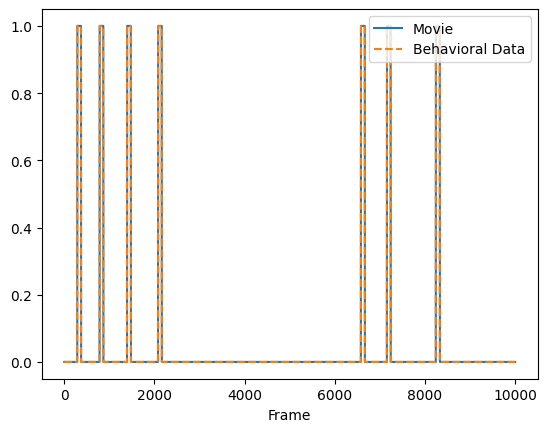

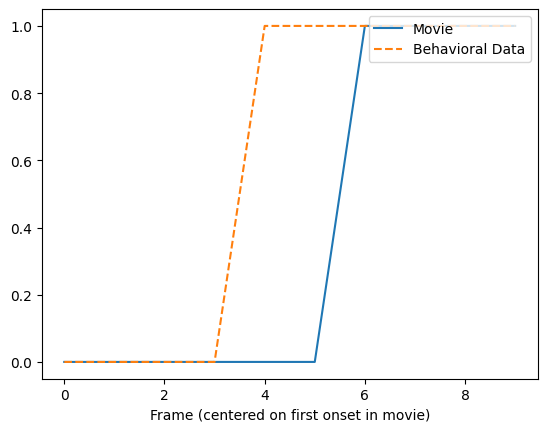

In [ ]:
## Generating ttl trace from df and movie

def generate_ttl_trace(df, fps, total_frames, date, recording):
    """
    Generates a TTL trace (1 for stimulus on, 0 for stimulus off) for each frame in the movie.

    Args:
    - df (pd.DataFrame): DataFrame containing 'BFMTime', 'Duration', and 'Date'.
    - fps (float): Frames per second of the movie.
    - total_frames (int): Total number of frames in the movie.
    - date (int or str): Date to filter trials (e.g., 240506).

    Returns:
    - np.ndarray: TTL trace with 1 (stimulus on) and 0 (stimulus off), one value per frame.
    """
    # Filter the dataframe to include only trials for the given date
    filtered_df = df[df["Date"] == int(date)]
    filtered_df = filtered_df[filtered_df["Recording"] == int(recording)]

    # Initialize the TTL trace with zeros (one entry per frame)
    ttl_trace = np.zeros(total_frames, dtype=int)

    # Loop through each trial in the filtered dataframe
    for _, trial in filtered_df.iterrows():
        # Compute the start and end frame indices for this trial
        start_frame = int(trial["BFMTime"] * fps)   # Convert BFMTime to frame index
        end_frame = int((trial["BFMTime"] + trial["Duration"]) * fps)  # Duration in frames

        # Ensure indices are within the bounds of the movie frames
        if start_frame < 0:
            continue  # Skip invalid trials
        if end_frame > total_frames:
            end_frame = total_frames  # Cap at the last frame

        # Set the frames for this trial to 1 (stimulus on)
        ttl_trace[start_frame:end_frame] = 1

    return ttl_trace

def get_ttl_trace(timestamps_table, timestamps_table_names, timeorigin, timebinning=1):
    """
    Extracts the TTL trace from the movie specs.

    Args:
    - timestamps_table (np.ndarray): Timestamps table containing TTL data.
    - timestamps_table_names (np.ndarray): Column names for the timestamps table.
    - timeorigin (int): Starting index for the TTL signal.
    - timebinning (int, optional): Time binning factor for downsampling (default: 1).

    Returns:
    - np.ndarray: Extracted TTL signal.
    """
  
    # Get the column index for 'behavior_ttl'
    ttl_column = timestamps_table_names.index("behavior_ttl")

    # Extract the raw TTL signal starting from `timeorigin`
    ttl_signal_raw = timestamps_table[ttl_column, int(timeorigin):]

    # Apply binning if `timebinning` is greater than 1
    if timebinning > 1:
        # Ensure the length of ttl_signal_raw is divisible by timebinning
        trimmed_length = len(ttl_signal_raw) - (len(ttl_signal_raw) % timebinning)
        ttl_signal_raw = ttl_signal_raw[:trimmed_length]
        
        # Reshape, average over bins, and round the result
        ttl_signal = np.round(np.mean(ttl_signal_raw.reshape(-1, timebinning), axis=1))
    else:
        ttl_signal = ttl_signal_raw

    return ttl_signal

def check_ttl_alignment(df, path_movie, tolerance=5, plot=False, date=240506, recording=1):
    """
    Checks if the TTL traces from the movie and behavioral data are aligned.

    Args:
    - ttl_movie (np.ndarray): TTL trace extracted from the movie.
    - ttl_df (np.ndarray): TTL trace generated from behavioral data.
    - tolerance (int, optional): Allowed frame difference for alignment. Default is 5.
    - plot (bool, optional): Wether to plot both traces for comparison (default is False)

    Returns:
    - str: "Aligned" if all onset/offset differences are within tolerance, else "Misaligned".
    """

    with h5py.File(path_movie, 'r') as mov_file:
        specs = mov_file["specs"]
        fps = specs["fps"][()][0][0][0]
        timeorigin = specs["timeorigin"][()][0][0][0]
        timebinning = specs["timebinning"][()][0][0]
        timestamps_table = specs["extra_specs"]["timestamps_table"][()].squeeze()
        timestamps_table_names = specs["extra_specs"]["timestamps_table_names"][()]
        timestamps_table_names = b''.join(timestamps_table_names.flatten()).decode("utf-8").split(';')

    ttl_movie = get_ttl_trace(timestamps_table, timestamps_table_names, timeorigin, timebinning)
    ttl_df = generate_ttl_trace(df, fps, len(ttl_movie), date, recording)

    # Find stimulus ONSET (0 -> 1) and OFFSET (1 -> 0) frames for both traces
    onsets_movie = np.where(np.diff(ttl_movie) == 1)[0] 
    offsets_movie = np.where(np.diff(ttl_movie) == -1)[0] 
    onsets_df = np.where(np.diff(ttl_df) == 1)[0] 
    offsets_df = np.where(np.diff(ttl_df) == -1)[0] 

    # Ensure equal number of onsets and offsets in both traces
    if len(onsets_movie) != len(onsets_df) or len(offsets_movie) != len(offsets_df):
        print(f"ERROR: Mismatch in number of stimuli: {len(onsets_movie)} in movie, {len(onsets_df)} in df")
        return "Misaligned"

    # Compute frame differences for onsets and offsets
    onset_diff = np.abs(onsets_movie - onsets_df)
    offset_diff = np.abs(offsets_movie - offsets_df)

    # Check if all differences are within tolerance
    if (onset_diff > tolerance).any() or (offset_diff > tolerance).any():
        print(f"ERROR: Some frame differences exceed tolerance of {tolerance} frames.")
        print(f"Onset differences: {onset_diff}")
        print(f"Offset differences: {offset_diff}")
        return "Misaligned"

    print(f"TTL Traces are aligned within ±{tolerance} frames.")

    if plot:
        if len(ttl_movie) > 10000:
            plt.plot(ttl_movie[0:10000])
            plt.plot(ttl_df[0:10000], ls='--')
        else:
            plt.plot(ttl_movie[0:min(len(ttl_movie), len(ttl_df))])
            plt.plot(ttl_df[0:min(len(ttl_movie), len(ttl_df))], ls='--')
        plt.legend(["Movie", "Behavioral Data"], loc=1)
        plt.xlabel("Frame")
        plt.show()
        plt.plot(ttl_movie[onsets_movie[1]-5:onsets_movie[1]+5])
        plt.plot(ttl_df[onsets_movie[1]-5:onsets_movie[1]+5], ls='--')
        plt.legend(["Movie", "Behavioral Data"], loc=1)
        plt.xlabel("Frame (centered on first onset in movie)")

    return "Aligned"

path_movie = "/Users/katiebrown/Library/CloudStorage/OneDrive-Stanford/Neuro_Project/Data/cG_unmixed_dFF.h5"
alignment_status = check_ttl_alignment(df, path_movie, plot=True)

## Checking files exist

In [6]:
def check_movie_files_exist(df):
    """
    Checks if all unique movie files listed in the 'MovieFile' column exist.

    Args:
    - df (pd.DataFrame): DataFrame containing a 'MovieFile' column with file paths.

    Returns:
    - check (str): "Files Missing" or "No FIles Missing"
    """
    # Get unique file paths from the "MovieFile" column
    unique_files = df["MovieFile"].unique()
    missing_files = []

    for file in unique_files:           # Check if each file exists
        if not os.path.exists(file):
            missing_files.append(file)

    # Print summary
    if len(missing_files) > 0:
        print(f"Missing Files: ", missing_files)
        check = "Files Missing"
    else:
        print("All Files Exist")
        check = "No Files Missing"

    return check

In [81]:
def filter_vdt_trials(df, xlsx_path):
    """
    Filters trials from df to include only those where the corresponding recording has Task = 'VDT'.
    
    Args:
    - df (pd.DataFrame): The trial dataframe containing 'Date', 'File', and 'AnimalCode'.
    - xlsx_path (str): Path to the xlsx file.
    - sheet_name (str): The name of the sheet containing recording metadata.
    
    Returns:
    - pd.DataFrame: The filtered dataframe containing only trials with Task = 'VDT'.
    """

    recording_info = pd.read_excel(xlsx_path, sheet_name="Sheet1")

    df2 = df.copy()

    df2["Date"] = df2["Date"].astype(str)
    recording_info["Date"] = recording_info["Date"].astype(str).str[2:]  # Convert YYYYMMDD → YYMMDD
    recording_info = recording_info.rename(columns={"Animal": "AnimalCode"})

    #Merge df with the xlsx data to bring in the Task column
    merged_df = df2.merge(
        recording_info,
        left_on=["AnimalCode", "Date", "File"],
        right_on=["AnimalCode", "Date", "File"],
        how="left"
    )

    # Identify recordings where Task is not 'VDT'
    flagged_recordings = merged_df.loc[merged_df["Task"] != "VDT", ["AnimalCode", "Date", "File"]].drop_duplicates()

    # Identify recordings missing from the xlsx file
    missing_recordings = merged_df.loc[merged_df["Task"].isna(), ["AnimalCode", "Date", "File"]].drop_duplicates()

    # Print missing recordings
    if not missing_recordings.empty:
        print("⚠️ The following recordings were not found in the xlsx file:")
        print(missing_recordings.to_string(index=False))

    # Print flagged recordings
    if not flagged_recordings.empty:
        print("⚠️ The following recordings were flagged for removal (Task != 'VDT'):")
        print(flagged_recordings.to_string(index=False))

    # # Keep only trials where Task is 'VDT'
    merged_df = merged_df[merged_df["Task"] == "VDT"].copy()
    merged_df.drop(columns=['Record#', 'identifier', 'Task', 'Active', 'VDT Behavior Quality.1'], inplace=True)

    return merged_df

xlsx_path = "/Users/katiebrown/Library/CloudStorage/OneDrive-Stanford/Neuro_Project/Data/Behavioral_Data/RecordingLogsVoltage.xlsx"
df = filter_vdt_trials(df, xlsx_path)

⚠️ The following recordings were flagged for removal (Task != 'VDT'):
AnimalCode   Date   File
 cfm001mjr 240522 meas00
